<a href="https://colab.research.google.com/github/padelacruz85/DAF2026/blob/main/%5BDATA_PREPROCESSING%5D_MotorPH_Products_List_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/padelacruz85/DAF2026/blob/main/Milestone_1/%5BDATA_PREPROCESSING%5D_MotorPH_Products_List_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MotorPH Products List 2025 – Data Preprocessing**

Source: `[RAW_DATA]_MotorPH_Products_List_2025.csv`  
Output: `[PROCESSED_DATA]_MotorPH_Products_List_2025.csv`

In [ ]:
# Connecting to google drive (Colab). Outside Colab this step is skipped automatically.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print("Running in Colab:", IN_COLAB)

Mounted at /content/drive
Running in Colab: True


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Load Data Set
# Folder in Google Drive that holds the raw CSV (edit if yours is different)
DRIVE_DIR = "/content/drive/MyDrive/4thYR_Term1/MO-IT106 - Data Analytics Fundamentals/Week 05/Dataset Preprocessing/"
RAW_FILE  = "[RAW_DATA]_MotorPH_Products_List_2025.csv"
GITHUB    = "https://raw.githubusercontent.com/padelacruz85/DAF2026/main/Raw_Data/"

def locate(fname):
    """Google Drive first, then a local Raw_Data/ folder, then the GitHub repo."""
    for p in [DRIVE_DIR + fname, "Raw_Data/" + fname, "../Raw_Data/" + fname]:
        if os.path.exists(p):
            return p
    return GITHUB + fname.replace("[", "%5B").replace("]", "%5D").replace(" ", "%20")

import os
path = locate(RAW_FILE)
df_prodList = pd.read_csv(path)
df_raw = df_prodList.copy()      # untouched backup for before/after comparison
print("Loaded from:", path)

Loaded from: /content/drive/MyDrive/4thYR_Term1/MO-IT106 - Data Analytics Fundamentals/Week 05/Dataset Preprocessing/[RAW_DATA]_MotorPH_Products_List_2025.csv


# **1. INSPECTING THE DATA SET**

In [ ]:
df_prodList.head(10)

,EntrNo,EntrName,EntrDetails,Manufacturing Date,Acquisiton,UnitPrice
0,1,Honda CBR500R,"Sport / Parallel-twin, liquid-cooled, 471cc, 6...",2021,2023,389000
1,2,Yamaha MT-15,"Naked bike / Single cylinder, liquid-cooled, 1...",2022,2023,178000
2,3,Kawasaki Ninja 400,"Sport / Parallel-twin, liquid-cooled, 399cc, 6...",2023,2024,340000
3,4,Suzuki Raider R150 Fi,"Underbone / Single cylinder, liquid-cooled, 15...",2020,2021,119900
4,5,Royal Enfield Classic 350,"Classic / Single cylinder, air-cooled, 349cc, ...",2022,2023,250000
5,6,CFMoto 300NK,"Naked bike / Single cylinder, liquid-cooled, 2...",2021,2022,165000
6,7,Bristol Veloce 500,"Cafe racer / Twin cylinder, air-cooled, 471cc,...",2022,2023,328000
7,8,KTM Duke 200,"Naked bike / Single cylinder, liquid-cooled, 1...",2023,2024,178000
8,9,Yamaha XSR155,"Retro / Single cylinder, liquid-cooled, 155cc,...",2022,2023,182000
9,10,Bajaj Dominar 400,"Sport touring / Single cylinder, liquid-cooled...",2021,2022,199900


In [ ]:
df_prodList.tail(10)

,EntrNo,EntrName,EntrDetails,Manufacturing Date,Acquisiton,UnitPrice
40,41,BMW R nineT,"Heritage / Flat twin, air/oil-cooled, 1170cc, ...",2023,2024,995000
41,42,Honda Rebel 1100,"Cruiser / Parallel-twin, liquid-cooled, 1084cc...",2023,2024,650000
42,43,KTM 790 Duke,"Naked bike / Parallel-twin, liquid-cooled, 799...",2023,2024,599000
43,44,CFMoto 300SR,"Sport / Single cylinder, liquid-cooled, 292cc,...",2023,2024,165000
44,45,Italjet Dragster 200,"Scooter / Single cylinder, liquid-cooled, 181c...",2023,2024,289000
45,46,Yamaha Serow 250,"Dual-sport / Single cylinder, air-cooled, 249c...",2020,2021,299000
46,47,Suzuki Burgman Street 125,"Scooter / Single cylinder, air-cooled, 124cc, CVT",2023,2024,80900
47,48,Zontes GK350,"Cafe racer / Single cylinder, liquid-cooled, 3...",2023,2024,269000
48,49,Moto Guzzi V7 Stone,"Heritage / V-twin, air-cooled, 853cc, 6-speed",2022,2023,689000
49,50,SYM Husky 150,"Underbone / Single cylinder, air-cooled, 150cc...",2022,2023,72900


In [ ]:
print("Rows, columns:", df_prodList.shape)
df_prodList.info()

Rows, columns: (50, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   EntrNo              50 non-null     int64 
 1   EntrName            50 non-null     object
 2   EntrDetails         50 non-null     object
 3   Manufacturing Date  50 non-null     int64 
 4   Acquisiton          50 non-null     int64 
 5   UnitPrice           50 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.5+ KB


In [ ]:
df_prodList.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EntrNo,50.0,NaN,NaN,NaN,25.5,14.57738,1.0,13.25,25.5,37.75,50.0
EntrName,50,50,Honda CBR500R,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EntrDetails,50,47,"Scooter / Single cylinder, liquid-cooled, 155c...",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Manufacturing Date,50.0,NaN,NaN,NaN,2022.06,0.998162,2020.0,2021.25,2022.0,2023.0,2023.0
Acquisiton,50.0,NaN,NaN,NaN,2023.08,0.986439,2021.0,2023.0,2023.0,2024.0,2024.0
UnitPrice,50.0,NaN,NaN,NaN,257872.0,183425.062316,48000.0,126425.0,204950.0,330250.0,995000.0


# **2. DETECTING ISSUES**

In [ ]:
# 2.1 Missing values (NaN, empty strings, whitespace-only)
print("NaN per column:\n", df_prodList.isna().sum(), "\n")
txt = df_prodList.select_dtypes(include=["object", "string"])
print("Blank strings per column:\n", (txt.apply(lambda s: s.str.strip().eq(""))).sum())

NaN per column:
 EntrNo                0
EntrName              0
EntrDetails           0
Manufacturing Date    0
Acquisiton            0
UnitPrice             0
dtype: int64 

Blank strings per column:
 EntrName       0
EntrDetails    0
dtype: int64


In [ ]:
# 2.2 Duplicates (full-row, ID, and product name)
print("Full-row duplicates   :", df_prodList.duplicated().sum())
print("Duplicate EntrNo      :", df_prodList["EntrNo"].duplicated().sum())
print("Duplicate product name:", df_prodList["EntrName"].str.strip().str.lower().duplicated().sum())
print("EntrNo sequential 1..n:", (df_prodList["EntrNo"] == np.arange(1, len(df_prodList) + 1)).all())

Full-row duplicates   : 0
Duplicate EntrNo      : 0
Duplicate product name: 0
EntrNo sequential 1..n: True


In [ ]:
# 2.3 Formatting: stray whitespace / double spaces in text fields
for col in ["EntrName", "EntrDetails"]:
    s = df_prodList[col]
    print(f"{col}: leading/trailing spaces = {(s != s.str.strip()).sum()}, double spaces = {s.str.contains('  ').sum()}")

# 2.4 Year validity
for col in ["Manufacturing Date", "Acquisiton"]:
    print(col, "->", df_prodList[col].min(), "to", df_prodList[col].max())
print("Acquired before manufactured:", (df_prodList["Acquisiton"] < df_prodList["Manufacturing Date"]).sum())

EntrName: leading/trailing spaces = 0, double spaces = 0
EntrDetails: leading/trailing spaces = 0, double spaces = 0
Manufacturing Date -> 2020 to 2023
Acquisiton -> 2021 to 2024
Acquired before manufactured: 0


In [ ]:
# 2.5 Price outliers (IQR rule + z-score)
q1, q3 = df_prodList["UnitPrice"].quantile([.25, .75])
upper = q3 + 1.5 * (q3 - q1)
print("IQR upper fence:", upper)
df_prodList[df_prodList["UnitPrice"] > upper]

IQR upper fence: 635987.5


,EntrNo,EntrName,EntrDetails,Manufacturing Date,Acquisiton,UnitPrice
40,41,BMW R nineT,"Heritage / Flat twin, air/oil-cooled, 1170cc, ...",2023,2024,995000
41,42,Honda Rebel 1100,"Cruiser / Parallel-twin, liquid-cooled, 1084cc...",2023,2024,650000
48,49,Moto Guzzi V7 Stone,"Heritage / V-twin, air-cooled, 853cc, 6-speed",2022,2023,689000


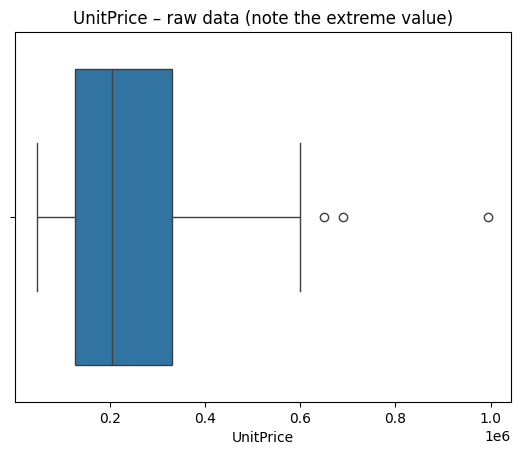

In [ ]:
sns.boxplot(x=df_prodList["UnitPrice"])
plt.title("UnitPrice – raw data (note the extreme value)")
plt.show()

### Findings
| # | Issue | Evidence |
|---|-------|----------|
| 1 | No missing values, no duplicates; `EntrNo` already runs 1–50 | checks above |
| 2 | `EntrDetails` packs 5 attributes (type, engine, cooling, displacement, transmission) into one text field | e.g. `Sport / Parallel-twin, liquid-cooled, 471cc, 6-speed` |
| 3 | Inconsistent text conventions (`Naked bike`, `Cafe racer`, `liquid-cooled`, `Parallel-twin` vs `Twin cylinder`) | lower-case second words, mixed hyphenation |
| 4 | Years and price stored as plain integers (price should be a decimal amount; years should be validated) | `info()` |
| 5 | Column names unclear / misspelled (`EntrNo`, `EntrName`, `Manufacturing Date` holds a year only, `Acquisiton`) | header row |
| 6 | **Entry 50 (SYM Husky 150) priced at 7,290,011** – ~7x the next-highest underbone-class price and far outside the IQR fence | outlier check |

# **3. CROSS-CHECKING THE OUTLIER**

The Q3 sales file records what MotorPH actually charged for this model, so we use it as evidence before changing the value.

In [ ]:
df_sales = pd.read_csv(locate("[RAW_DATA]_MotorPH_Sales Data-3rd Quarter-Year 2025.csv"))
husky = df_sales.loc[df_sales["product"].str.strip() == "SYM Husky 150", "unitprice"].unique()
print("Unit price(s) for SYM Husky 150 in Q3 sales:", husky)

Unit price(s) for SYM Husky 150 in Q3 sales: [72900]


In [ ]:
# The sales price (72,900) matches the listed value with the extra digits "11" appended
# (7290011 -> 72900), i.e. a data-entry error. Correct it using the sales evidence.
bad = df_prodList["EntrName"].eq("SYM Husky 150")
df_prodList.loc[bad, "UnitPrice"] = int(husky[0])
df_prodList.loc[bad, ["EntrNo", "EntrName", "UnitPrice"]]

,EntrNo,EntrName,UnitPrice
49,50,SYM Husky 150,72900


# **4. PREPROCESSING**

In [ ]:
# 4.1 Missing values & duplicates (none found – kept as safeguards so the pipeline is reusable)
df_prodList = df_prodList.dropna(how="all")
df_prodList = df_prodList.drop_duplicates()
df_prodList = df_prodList.drop_duplicates(subset="EntrName", keep="first")
df_prodList.shape

(50, 6)

In [ ]:
# 4.2 Trim whitespace and normalise internal spacing
for col in ["EntrName", "EntrDetails"]:
    df_prodList[col] = df_prodList[col].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)

In [ ]:
# 4.3 Split EntrDetails into separate attributes
details = df_prodList["EntrDetails"].str.extract(
    r"^(?P<type>[^/]+?)\s*/\s*(?P<engine>[^,]+),\s*(?P<cooling>[^,]+),\s*(?P<cc>\d+)\s*cc,\s*(?P<trans>.+)$"
)
print("Rows that failed to parse:", details.isna().any(axis=1).sum())
details.head()

Rows that failed to parse: 0


,type,engine,cooling,cc,trans
0,Sport,Parallel-twin,liquid-cooled,471,6-speed
1,Naked bike,Single cylinder,liquid-cooled,155,6-speed
2,Sport,Parallel-twin,liquid-cooled,399,6-speed
3,Underbone,Single cylinder,liquid-cooled,150,6-speed
4,Classic,Single cylinder,air-cooled,349,5-speed


In [ ]:
# 4.4 Standardise labels (consistent capitalisation / hyphenation)
def title_keep_hyphen(s):
    return "-".join(w.capitalize() for w in s.split("-"))

prod_type = details["type"].str.strip().str.title()                      # Naked Bike, Cafe Racer, Dual-Sport
engine    = (details["engine"].str.strip().str.title()
             .str.replace("Parallel-Twin", "Parallel Twin")
             .str.replace("V-Twin", "V-Twin"))
cooling   = details["cooling"].str.strip().apply(lambda s: "/".join(title_keep_hyphen(x) for x in s.split("/")))
trans     = details["trans"].str.strip().str.replace("-speed", "-Speed", regex=False)  # 6-Speed, CVT

prod_type = prod_type.str.replace("Dual-Sport", "Dual-Sport")
print(sorted(prod_type.unique())); print(sorted(engine.unique()))
print(sorted(cooling.unique()));   print(sorted(trans.unique()))

['Adventure', 'Cafe Racer', 'Classic', 'Commuter', 'Cruiser', 'Dual-Sport', 'Heritage', 'Naked Bike', 'Retro', 'Scooter', 'Scrambler', 'Sport', 'Sport Touring', 'Standard', 'Street', 'Touring', 'Underbone']
['Flat Twin', 'Parallel Twin', 'Single Cylinder', 'Twin Cylinder', 'V-Twin']
['Air-Cooled', 'Air/Oil-Cooled', 'Liquid-Cooled', 'Oil-Cooled']
['4-Speed', '5-Speed', '6-Speed', 'CVT']


In [ ]:
# 4.5 Build the structured table with correct data types
df_clean = pd.DataFrame({
    "Product ID Number":   df_prodList["EntrNo"].astype("int64"),
    "Product Name":        df_prodList["EntrName"].astype("string"),
    "Product Type":        prod_type.astype("string"),
    "Engine Type":         engine.astype("string"),
    "Cooling System":      cooling.astype("string"),
    "Engine Displacement (cc)": details["cc"].astype("int64"),
    "Transmission":        trans.astype("string"),
    "Manufacturing Year":  df_prodList["Manufacturing Date"].astype("int64"),
    "Acquisition Year":    df_prodList["Acquisiton"].astype("int64"),
    "Unit Price (PHP)":    df_prodList["UnitPrice"].astype("float64").round(2),
}).reset_index(drop=True)

# Product ID: make sequential 1..n in listed order
df_clean["Product ID Number"] = np.arange(1, len(df_clean) + 1)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Product ID Number         50 non-null     int64  
 1   Product Name              50 non-null     string 
 2   Product Type              50 non-null     string 
 3   Engine Type               50 non-null     string 
 4   Cooling System            50 non-null     string 
 5   Engine Displacement (cc)  50 non-null     int64  
 6   Transmission              50 non-null     string 
 7   Manufacturing Year        50 non-null     int64  
 8   Acquisition Year          50 non-null     int64  
 9   Unit Price (PHP)          50 non-null     float64
dtypes: float64(1), int64(4), string(5)
memory usage: 4.0 KB


# **5. VALIDATION (REVIEW PASS)**

In [ ]:
checks = {
    "No missing values":              df_clean.isna().sum().sum() == 0,
    "No duplicate rows":              not df_clean.duplicated().any(),
    "No duplicate product names":     not df_clean["Product Name"].duplicated().any(),
    "Product ID sequential 1..n":     (df_clean["Product ID Number"] == np.arange(1, len(df_clean)+1)).all(),
    "Manufacturing year valid (2000-2025)": df_clean["Manufacturing Year"].between(2000, 2025).all(),
    "Acquisition year valid (2000-2025)":   df_clean["Acquisition Year"].between(2000, 2025).all(),
    "Acquired on/after manufacture":  (df_clean["Acquisition Year"] >= df_clean["Manufacturing Year"]).all(),
    "Unit price > 0":                 (df_clean["Unit Price (PHP)"] > 0).all(),
    "No leading/trailing spaces":     all((df_clean[c] == df_clean[c].str.strip()).all()
                                          for c in df_clean.select_dtypes("string").columns),
    "Price outliers (IQR) remaining": (df_clean["Unit Price (PHP)"] > df_clean["Unit Price (PHP)"].quantile(.75)
                                        + 1.5*(df_clean["Unit Price (PHP)"].quantile(.75) - df_clean["Unit Price (PHP)"].quantile(.25))).sum(),
}
for k, v in checks.items():
    print(f"{k:42s}: {v}")

No missing values                         : True
No duplicate rows                         : True
No duplicate product names                : True
Product ID sequential 1..n                : True
Manufacturing year valid (2000-2025)      : True
Acquisition year valid (2000-2025)        : True
Acquired on/after manufacture             : True
Unit price > 0                            : True
No leading/trailing spaces                : True
Price outliers (IQR) remaining            : 3


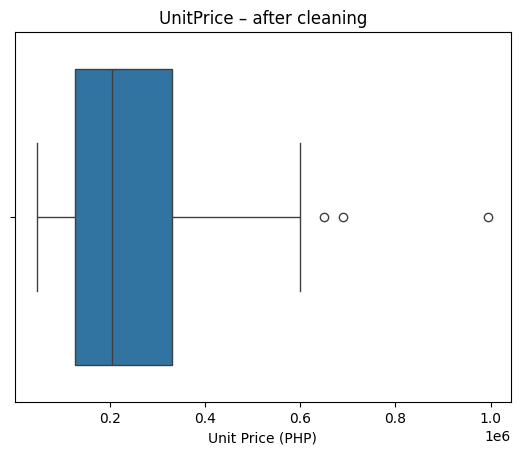

,Product Name,Unit Price (PHP)
40,BMW R nineT,995000.0
48,Moto Guzzi V7 Stone,689000.0
41,Honda Rebel 1100,650000.0
42,KTM 790 Duke,599000.0
31,Harley-Davidson Street 750,499000.0


In [ ]:
# Remaining high-priced units are genuine premium models (BMW R nineT, Honda Rebel 1100, ...), not errors
sns.boxplot(x=df_clean["Unit Price (PHP)"]); plt.title("UnitPrice – after cleaning"); plt.show()
df_clean.nlargest(5, "Unit Price (PHP)")[["Product Name", "Unit Price (PHP)"]]

# **6. EXPORT**

In [ ]:
OUT_FILE = "[PROCESSED_DATA]_MotorPH_Products_List_2025.csv"
df_clean.to_csv(OUT_FILE, index=False, encoding="utf-8")        # saved in the Colab session
if IN_COLAB:
    df_clean.to_csv(DRIVE_DIR + OUT_FILE, index=False, encoding="utf-8")   # saved to Google Drive
    from google.colab import files
    files.download(OUT_FILE)                                      # download to your computer
print("Saved:", OUT_FILE, df_clean.shape)
df_clean.head(10)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: [PROCESSED_DATA]_MotorPH_Products_List_2025.csv (50, 10)


,Product ID Number,Product Name,Product Type,Engine Type,Cooling System,Engine Displacement (cc),Transmission,Manufacturing Year,Acquisition Year,Unit Price (PHP)
0,1,Honda CBR500R,Sport,Parallel Twin,Liquid-Cooled,471,6-Speed,2021,2023,389000.0
1,2,Yamaha MT-15,Naked Bike,Single Cylinder,Liquid-Cooled,155,6-Speed,2022,2023,178000.0
2,3,Kawasaki Ninja 400,Sport,Parallel Twin,Liquid-Cooled,399,6-Speed,2023,2024,340000.0
3,4,Suzuki Raider R150 Fi,Underbone,Single Cylinder,Liquid-Cooled,150,6-Speed,2020,2021,119900.0
4,5,Royal Enfield Classic 350,Classic,Single Cylinder,Air-Cooled,349,5-Speed,2022,2023,250000.0
5,6,CFMoto 300NK,Naked Bike,Single Cylinder,Liquid-Cooled,292,6-Speed,2021,2022,165000.0
6,7,Bristol Veloce 500,Cafe Racer,Twin Cylinder,Air-Cooled,471,6-Speed,2022,2023,328000.0
7,8,KTM Duke 200,Naked Bike,Single Cylinder,Liquid-Cooled,199,6-Speed,2023,2024,178000.0
8,9,Yamaha XSR155,Retro,Single Cylinder,Liquid-Cooled,155,6-Speed,2022,2023,182000.0
9,10,Bajaj Dominar 400,Sport Touring,Single Cylinder,Liquid-Cooled,373,6-Speed,2021,2022,199900.0
